Размышления.
В задании у нас есть готовые целевые переменны:

- `IC50`
- `CC50`
- `SI`
- и бинарные таргеты на их основе

Это значит, что задача уже поставлена как:

- **регрессия** — предсказать численное значение
- **классификация** — предсказать класс

Это обучение с учителем.




Начну с загрузки данных

In [ ]:

import pandas as pd
import numpy as np


sheet_id = "1q-nbWuFrfrIBMXmZfNW78N3bx5v60Vb9"

# Формирую ссылку для экспорта в CSV
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

# Загружаю данные
df = pd.read_csv(url)

# Проверяю, что всё загрузилось корректно
print("Размер датасета:", df.shape)
display(df.head())

Размер датасета: (1001, 214)


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


Проверка структуры и пропусков

In [ ]:
# Смотрю на структуру данных:
# типы признаков, пропуски и дубликаты

# Общая информация
df.info()

# Пропуски
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

# Дубликаты
print('Количество дубликатов:', df.duplicated().sum())

# Базовая статистика
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB


,0
MaxAbsPartialCharge,3
MinAbsPartialCharge,3
MaxPartialCharge,3
MinPartialCharge,3
BCUT2D_MWLOW,3
BCUT2D_MWHI,3
BCUT2D_MRLOW,3
BCUT2D_MRHI,3
BCUT2D_LOGPLOW,3
BCUT2D_LOGPHI,3


Количество дубликатов: 0


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1001.0,500.000000,289.108111,0.000000,250.000000,500.000000,750.000000,1000.000000
"IC50, mM",1001.0,222.805156,402.169734,0.003517,12.515396,46.585183,224.975928,4128.529377
"CC50, mM",1001.0,589.110728,642.867508,0.700808,99.999036,411.039342,894.089177,4538.976189
SI,1001.0,72.508823,684.482739,0.011489,1.433333,3.846154,16.566667,15620.600000
MaxAbsEStateIndex,1001.0,10.831637,3.307505,2.321942,9.252350,12.179236,13.167843,15.933463
...,...,...,...,...,...,...,...,...
fr_thiazole,1001.0,0.051948,0.222033,0.000000,0.000000,0.000000,0.000000,1.000000
fr_thiocyan,1001.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
fr_thiophene,1001.0,0.069930,0.255157,0.000000,0.000000,0.000000,0.000000,1.000000
fr_unbrch_alkane,1001.0,0.204795,1.215326,0.000000,0.000000,0.000000,0.000000,20.000000


### Что видно

- В датасете **1001 строка и 214 признаков** — то есть признаков очень много
- Все признаки **числовые** (`int + float`), что сильно упрощает
- Есть столбец **`Unnamed: 0`**:
  по статистике видно, что это просто индекс от 0 до 1000;
  смысла для модели в нём нет → удалять.

- Пропуски:
  их **очень мало — всего по 3 значения в нескольких столбцах**;
  затронуты признаки типа:
     `MaxPartialCharge`
    `MinPartialCharge`
     `BCUT2D_*`
   не придётся делать сложную обработку.

- Дубликатов **нет вообще** — это тоже хороший сигнал.

Теперь по таргетам:

- **IC50**
   медиана ≈ **46.6**
   максимум аж **4000+**
  распределение явно с длинным хвостом (будут выбросы)

- **CC50**
   медиана ≈ **411**
  тоже большой разброс

- **SI**
   медиана ≈ **3.85**
   максимум **15620 (!!)**
  -тут вообще сильнейший перекос — почти наверняка понадобится логарифмирование

Отдельно заметила:

- много бинарных/почти бинарных признаков (`fr_*`)
   например `fr_thiazole`, `fr_thiophene`
  часто 0/1 или почти всё 0
 есть признаки с маленькой вариативностью - потенциально на удаление

### Вывод после этого шага

Данные в целом очень «чистые»:
- почти нет пропусков
- нет дубликатов
- все признаки  числовые

Но есть два важных момента:

1. **Очень сильные выбросы и перекосы в таргетах (особенно SI)**
2. **Очень много признаков (214)** → без отбора признаков модели могут переобучаться

Следующее действие:
- проверить связь между IC50, CC50 и SI  
- и отдельно убедиться, что SI действительно считается как отношение

In [ ]:
# Проверяю гипотезу: SI ≈ CC50 / IC50

# Создаю вычисленное значение SI
df['SI_calc'] = df['CC50, mM'] / df['IC50, mM']

# Считаю разницу
df['SI_diff'] = df['SI'] - df['SI_calc']

# Смотрю максимальное отклонение
print('Максимальное отклонение:', df['SI_diff'].abs().max())

# Смотрю несколько строк
display(df[['IC50, mM', 'CC50, mM', 'SI', 'SI_calc', 'SI_diff']].head())

# Корреляции между таргетами
display(df[['IC50, mM', 'CC50, mM', 'SI']].corr())

Максимальное отклонение: 1.8629798432812095e-06


,"IC50, mM","CC50, mM",SI,SI_calc,SI_diff
0,6.239374,175.482382,28.125000,28.125000,-4.507662e-09
1,0.771831,5.402819,7.000000,7.000000,-5.182477e-10
2,223.808778,161.142320,0.720000,0.720000,7.148948e-11
3,1.705624,107.855654,63.235294,63.235294,9.250535e-09
4,107.131532,139.270991,1.300000,1.300000,-5.600593e-10


,"IC50, mM","CC50, mM",SI
"IC50, mM",1.000000,0.521346,-0.056604
"CC50, mM",0.521346,1.000000,-0.006818
SI,-0.056604,-0.006818,1.000000


### Что проверяю

- Проверяю, считается ли **SI как отношение CC50 / IC50**
- Смотрю, есть ли отклонения (ошибки округления или нет)
- Дополнительно смотрю корреляции между таргетами

### Что получилось

- Максимальное отклонение между реальным и рассчитанным SI:
  **≈ 1.86e-06** → это практически ноль

- По строкам видно, что:
   `SI` и `SI_calc` совпадают до 6 знаков
   разница только из-за округления

- Корреляции:
   IC50 ↔ CC50: **0.52** (умеренная связь)
   IC50 ↔ SI: **-0.056** (почти нет связи)
  CC50 ↔ SI: **-0.0068** (вообще нет связи)

### Вывод

- **SI = CC50 / IC50 (фактически точно)**  
- Это полностью **производный таргет**

### Что это значит для моделей

- Нельзя использовать IC50 и CC50 как признаки при предсказании SI - будет утечка  
- Задача регрессии SI по сути:
  либо избыточна  
 либо должна решаться **без этих двух признаков**

- Классификация по SI (медиана, >8) — тоже под этим ограничением

Следующее:
- начинаю чистку признаков (Unnamed + пропуски + низкая вариативность)

In [ ]:
# 1. Удаляю служебный столбец
df = df.drop(columns=['Unnamed: 0'])

# 2. Обработка пропусков (их мало - просто медианой)
df = df.fillna(df.median(numeric_only=True))

# 3. Удаление признаков с низкой вариативностью
# (почти константы — не дают сигнал модели)

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(df.drop(columns=['IC50, mM', 'CC50, mM', 'SI']))

low_var_cols = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI']).columns[~selector.get_support()]

print('Удаляем признаки с низкой вариативностью:', len(low_var_cols))

df = df.drop(columns=low_var_cols)

print('Новый размер датасета:', df.shape)

Удаляем признаки с низкой вариативностью: 35
Новый размер датасета: (1001, 180)


### Что делаю

- Удаляю `Unnamed: 0` — это просто индекс  
- Пропуски заполняю медианой  
- Убираю признаки с низкой вариативностью

### Что получилось

- После удаления `Unnamed: 0` и чистки осталось **180 столбцов**
- По порогу вариативности удалилось **35 признаков**
- Пропуски закрыты медианой, потери строк нет

### Вывод

На этом шаге я сделала базовую техническую очистку без серьезного вмешательства в данные.  
Размерность уже стала немного компактнее: было **214 столбцов**, осталось **180**.

Следующее:
- подготовка отдельных таргетов для регрессии и классификации

In [ ]:
# Создаю копию, чтобы не потерять исходные данные
df_model = df.copy()

# --- Регрессия ---
y_ic50 = df_model['IC50, mM']
y_cc50 = df_model['CC50, mM']
y_si   = df_model['SI']

# --- Классификация (по медиане) ---
ic50_median = y_ic50.median()
cc50_median = y_cc50.median()
si_median   = y_si.median()

df_model['IC50_class'] = (y_ic50 > ic50_median).astype(int)
df_model['CC50_class'] = (y_cc50 > cc50_median).astype(int)
df_model['SI_class_median'] = (y_si > si_median).astype(int)

# --- Классификация (SI > 8) ---
df_model['SI_class_8'] = (y_si > 8).astype(int)

# Проверяю баланс классов
print('IC50 class:\n', df_model['IC50_class'].value_counts(), '\n')
print('CC50 class:\n', df_model['CC50_class'].value_counts(), '\n')
print('SI median class:\n', df_model['SI_class_median'].value_counts(), '\n')
print('SI > 8 class:\n', df_model['SI_class_8'].value_counts())

IC50 class:
 IC50_class
0    501
1    500
Name: count, dtype: int64 

CC50 class:
 CC50_class
0    502
1    499
Name: count, dtype: int64 

SI median class:
 SI_class_median
0    501
1    500
Name: count, dtype: int64 

SI > 8 class:
 SI_class_8
0    644
1    357
Name: count, dtype: int64


### Что делаю

- Формирую таргеты для всех задач:
   регрессия: IC50, CC50, SI  
   классификация:
     IC50 > медианы  
     CC50 > медианы  
     SI > медианы  
     SI > 8  

### Что получилось

- **IC50_class**
  0: 501  
   1: 500  
   идеально сбалансировано

- **CC50_class**
   0: 502  
   1: 499  
   тоже почти идеально

- **SI_class_median**
   0: 501  
   1: 500  
   идеально

- **SI_class_8**
   0: 644  
   1: 357  
   уже есть перекос (примерно 64% / 36%)

### Вывод

- Задачи по медиане — **идеально сбалансированные**, можно спокойно использовать accuracy  
- Задача **SI > 8** — несбалансированная - лучше учитывать:
  - precision / recall  
  - или F1  

Следующее:
- формирую признаки X с учётом того, что **IC50 и CC50 нельзя использовать при моделировании SI**

In [ ]:
# Базовый набор признаков (без таргетов и классов)
base_features = df_model.drop(columns=[
    'IC50, mM', 'CC50, mM', 'SI',
    'IC50_class', 'CC50_class', 'SI_class_median', 'SI_class_8'
])

#  Для IC50
X_ic50 = base_features.copy()

#  Для CC50
X_cc50 = base_features.copy()

#  Для SI
# Убираю IC50 и CC50, чтобы не было утечки
X_si = base_features.drop(columns=['IC50, mM', 'CC50, mM'], errors='ignore')

print('X_ic50:', X_ic50.shape)
print('X_cc50:', X_cc50.shape)
print('X_si:', X_si.shape)

X_ic50: (1001, 177)
X_cc50: (1001, 177)
X_si: (1001, 177)


### Что делаю

- Формирую общий набор признаков (без таргетов и классов)
- Для IC50 и CC50 использую все признаки
- Для SI **удаляю IC50 и CC50**

### Почему так

- SI = CC50 / IC50 - если оставить их в X, модель будет не корректной
- для IC50 и CC50 таких ограничений нет

### Что получилось

- X_ic50 и X_cc50 — полный набор признаков  
- X_si — тот же набор, но без IC50 и CC50  

Следующее:
- разбиваю данные на train/test и начинаю первую модель (IC50)

In [ ]:
# Проверка наборов признаков перед моделированием, какие признаки реально попали в X
# и отдельно фиксирую, что сейчас размеры у всех наборов одинаковые

print('X_ic50:', X_ic50.shape)
print('X_cc50:', X_cc50.shape)
print('X_si:', X_si.shape)

print('\nIC50, mM в X_ic50:', 'IC50, mM' in X_ic50.columns)
print('CC50, mM в X_ic50:', 'CC50, mM' in X_ic50.columns)

print('\nIC50, mM в X_cc50:', 'IC50, mM' in X_cc50.columns)
print('CC50, mM в X_cc50:', 'CC50, mM' in X_cc50.columns)

print('\nIC50, mM в X_si:', 'IC50, mM' in X_si.columns)
print('CC50, mM в X_si:', 'CC50, mM' in X_si.columns)

X_ic50: (1001, 177)
X_cc50: (1001, 177)
X_si: (1001, 177)

IC50, mM в X_ic50: False
CC50, mM в X_ic50: False

IC50, mM в X_cc50: False
CC50, mM в X_cc50: False

IC50, mM в X_si: False
CC50, mM в X_si: False


### Что проверяю

- Какие признаки реально входят в X  
- Есть ли там `IC50, mM` и `CC50, mM`

### Что получилось

- Все наборы имеют одинаковый размер: **(1001, 177)**
- В `X_ic50`, `X_cc50` и `X_si`:
   `IC50, mM` → отсутствует  
   `CC50, mM` → отсутствует  

### Вывод

- Таргеты корректно исключены из признаков  
- Утечки данных нет  
- Все три набора признаков сейчас идентичны  

Следующее:
- разбиваю данные и начинаю модель для **IC50**

In [ ]:
# Разделение данных и baseline для регрессии IC50
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_ic50, y_ic50, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

# Базовая модель — линейная регрессия
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

# Предсказание
y_pred = model.predict(X_test)

# Метрики
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"R2: {r2:.3f}")

(800, 177) (201, 177)
MAE: 270.908
MSE: 239147.531
R2: 0.283


### Что делаю

- Деление: **800 train / 201 test**
- Обучаю базовую модель — LinearRegression
- Считаю MAE, MSE, R2

### Что получилось

- **MAE: 270.9**
- **MSE: 239147.5**
- **R2: 0.283**

### Вывод

- Модель объясняет ~28% дисперсии - это слабый baseline  
- Ошибка достаточно большая - линейная зависимость явно не покрывает данные  

Следующее:
- пробую нелинейные модели (деревья / ансамбли)

In [ ]:
# Модель на деревьях Decision Tree
from sklearn.tree import DecisionTreeRegressor

# Обучаю дерево
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

# Предсказание
y_pred_tree = tree.predict(X_test)

# Метрики
mae = mean_absolute_error(y_test, y_pred_tree)
mse = mean_squared_error(y_test, y_pred_tree)
r2 = r2_score(y_test, y_pred_tree)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"R2: {r2:.3f}")

MAE: 151.732
MSE: 156425.911
R2: 0.531


### Что делаю

- Обучаю DecisionTreeRegressor без настройки параметров  
- Сравниваю с линейной моделью  

### Что получилось

- **MAE: 151.7**
- **MSE: 156425.9**
- **R2: 0.531**

### Вывод

- Результат сильно лучше, чем у линейной модели  
- R2 вырос с **0.28 - 0.53**  
- Ошибка заметно снизилась  

 значит, в данных есть **нелинейные зависимости**, которые дерево уже отслеживает

Следующее:
- настроить глубину дерева, чтобы убрать переобучение

In [ ]:
# Настройка глубины дерева
from sklearn.model_selection import GridSearchCV

# Подбор max_depth
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print('Лучшая глубина:', grid.best_params_)

# Обучаю лучшую модель
best_tree = grid.best_estimator_

y_pred_best = best_tree.predict(X_test)

# Метрики
mae = mean_absolute_error(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"R2: {r2:.3f}")

Лучшая глубина: {'max_depth': 5}
MAE: 185.935
MSE: 174786.478
R2: 0.476


### Что делаю

- Подбираю `max_depth` через GridSearchCV  
- Использую 5-fold CV  
- Метрика — R2  

### Что получилось

- Лучшая глубина: **5**
- **MAE: 185.9**
- **MSE: 174786.5**
- **R2: 0.476**

### Вывод

- После ограничения глубины качество **упало** (R2: 0.53 → 0.48)  
- Значит, предыдущее дерево было переобучено, но при этом давало лучшее качество на тесте  

 простое ограничение глубины не дало выигрыша  

Следующее:
- пробую ансамбли (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Обучаю Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Предсказание
y_pred_rf = rf.predict(X_test)

# Метрики
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"R2: {r2:.3f}")

MAE: 138.908
MSE: 120520.091
R2: 0.639


### Что делаю

- Обучаю RandomForest (200 деревьев)  
- Без подбора параметров  

### Что получилось

- **MAE: 138.9**
- **MSE: 120520.1**
- **R2: 0.639**

### Вывод

- Лучший результат на текущий момент  
- R2 вырос до **0.64**  
- Ошибка стала заметно ниже  

ансамбль работает лучше одиночного дерева  

Следующее:
- настраиваю гиперпараметры Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print('Лучшие параметры:', grid_rf.best_params_)

best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

# Метрики
mae = mean_absolute_error(y_test, y_pred_best_rf)
mse = mean_squared_error(y_test, y_pred_best_rf)
r2 = r2_score(y_test, y_pred_best_rf)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"R2: {r2:.3f}")

Лучшие параметры: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
MAE: 140.067
MSE: 121096.033
R2: 0.637


### Что делаю

- Подбираю параметры Random Forest через GridSearchCV  
- Перебираю:
   `n_estimators`
   `max_depth`
   `min_samples_split`  

### Что получилось

- Лучшие параметры:
   `n_estimators = 300`
   `max_depth = 10`
   `min_samples_split = 2`

- **MAE: 140.1**
- **MSE: 121096.0**
- **R2: 0.637**

### Вывод

- Результат почти не изменился (R2: 0.639 - 0.637)  
- Значит, базовый Random Forest уже был близок к оптимальному  
- Перебор параметров не дал существенного улучшения  

 фиксирую Random Forest как лучшую модель для IC50  

Следующее:
- перехожу к задаче **регрессии CC50**

In [ ]:
# Деление данных
X_train, X_test, y_train, y_test = train_test_split(
    X_cc50, y_cc50, test_size=0.2, random_state=42
)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print('Linear Regression:')
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.3f}")
print(f"R2: {r2_score(y_test, y_pred_lr):.3f}")

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print('\nRandom Forest:')
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_rf):.3f}")
print(f"R2: {r2_score(y_test, y_pred_rf):.3f}")

Linear Regression:
MAE: 375.790
MSE: 324805.354
R2: 0.374

Random Forest:
MAE: 270.807
MSE: 191091.684
R2: 0.631


### Что делаю

- Строю две модели для CC50:
   Linear Regression  
   Random Forest  

### Что получилось

**Linear Regression:**
- MAE: **375.8**
- MSE: **324805.4**
- R2: **0.374**

**Random Forest:**
- MAE: **270.8**
- MSE: **191091.7**
- R2: **0.631**

### Вывод

- Random Forest снова сильно лучше линейной модели  
- R2: **0.37 - 0.63**  
- Ошибка заметно снизилась  

 картина полностью повторяет IC50:  
линейная модель слабая, ансамбль работает хорошо  

Следующее:
- настраиваю Random Forest для CC50

In [ ]:
# Подбор гиперпараметров Random Forest для CC50
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print('Лучшие параметры:', grid_rf.best_params_)

best_rf = grid_rf.best_estimator_

y_pred = best_rf.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")
print(f"R2: {r2_score(y_test, y_pred):.3f}")

Лучшие параметры: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
MAE: 273.181
MSE: 194922.823
R2: 0.624


### Что делаю

- Подбираю параметры Random Forest через GridSearchCV  
- Перебираю:
   `n_estimators`
   `max_depth`
   `min_samples_split`

### Что получилось

- Лучшие параметры:
   `n_estimators = 200`
   `max_depth = None`
   `min_samples_split = 5`

- **MAE: 273.2**
- **MSE: 194922.8**
- **R2: 0.624**

### Вывод

- Качество немного хуже, чем у базового RF (R2: 0.631 - 0.624)  
- Подбор гиперпараметров снова не дал улучшения  

→ фиксирую обычный Random Forest как лучшую модель для CC50  

Следующее:
- перехожу к регрессии **SI**

In [ ]:
# Базовая модель для регрессии SI
# Деление данных
X_train, X_test, y_train, y_test = train_test_split(
    X_si, y_si, test_size=0.2, random_state=42
)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print('Linear Regression:')
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.3f}")
print(f"R2: {r2_score(y_test, y_pred_lr):.3f}")

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print('\nRandom Forest:')
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_rf):.3f}")
print(f"R2: {r2_score(y_test, y_pred_rf):.3f}")

Linear Regression:
MAE: 0.000
MSE: 0.000
R2: 1.000

Random Forest:
MAE: 96.651
MSE: 909416.831
R2: 0.547


### Что делаю

- Строю модели для SI:
   Linear Regression  
   Random Forest  
- Использую признаки без IC50 и CC50  

### Что получилось

**Linear Regression:**
- MAE: **0.000**
- MSE: **0.000**
- R2: **1.000**

**Random Forest:**
- MAE: **96.7**
- MSE: **909416.8**
- R2: **0.547**

### Вывод

- Линейная модель дала **идеальный результат** - это подозрительно  
- Скорее всего, в данных осталась **утечка (SI вычисляется через другие признаки)**  

- Random Forest показывает более реалистичный результат:
   R2 ≈ **0.55**

 задача предсказания SI напрямую некорректна без дополнительной очистки  

Следующее:
- проверить признаки на утечку (feature leakage)

In [ ]:
# Смотрю, какие признаки сильнее всего коррелируют с SI
corr = df_model.corr(numeric_only=True)['SI'].abs().sort_values(ascending=False)

# Топ-20 признаков
display(corr.head(20))

# Исключаю сам SI
leak_candidates = corr.drop('SI')

# Беру подозрительно высокие корреляции
suspicious = leak_candidates[leak_candidates > 0.95]
print('Подозрительные признаки:')
display(suspicious)

,SI
SI,1.000000
SI_calc,1.000000
BalabanJ,0.162955
fr_NH2,0.160470
SI_class_8,0.137194
RingCount,0.124444
SI_class_median,0.103555
fr_Al_COO,0.102414
fr_COO2,0.101115
fr_COO,0.101115


Подозрительные признаки:


,SI
SI_calc,1.0


### Что делаю

- Считаю корреляции всех признаков с SI  
- Ищу признаки с очень высокой корреляцией  

### Что получилось

- **SI_calc - корреляция = 1.0**
- Остальные признаки:
   ~0.16 и ниже → нормальные, не критичные

### Вывод

- Найдена явная утечка: **SI_calc**
- Именно она даёт идеальный результат линейной модели  

 модель просто восстанавливает SI через формулу  

### Решение

- Удаляю `SI_calc` из признаков  
- Перестраиваю модели для SI  

Следующее:
- повторное обучение модели SI без утечки

In [ ]:
# Удаляю SI_calc из признаков
X_si_clean = X_si.drop(columns=['SI_calc'], errors='ignore')

# Деление
X_train, X_test, y_train, y_test = train_test_split(
    X_si_clean, y_si, test_size=0.2, random_state=42
)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print('Linear Regression:')
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.3f}")
print(f"R2: {r2_score(y_test, y_pred_lr):.3f}")

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print('\nRandom Forest:')
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_rf):.3f}")
print(f"R2: {r2_score(y_test, y_pred_rf):.3f}")

Linear Regression:
MAE: 224.130
MSE: 1889660.182
R2: 0.059

Random Forest:
MAE: 191.686
MSE: 1835018.563
R2: 0.086


### Что делаю

- Удаляю `SI_calc`  
- Перестраиваю модели для SI без утечки  

### Что получилось

**Linear Regression:**
- MAE: **224.1**
- MSE: **1889660.2**
- R2: **0.059**

**Random Forest:**
- MAE: **191.7**
- MSE: **1835018.6**
- R2: **0.086**

### Вывод

- Качество резко упало  теперь оценка более честной
- R2 почти нулевой - признаки **плохо объясняют SI**  
- Даже Random Forest даёт слабый результат  

- напрямую предсказывать SI по этим признакам почти невозможно  

Следующее:
- перейти к задачам классификации

In [ ]:
# Классификация: IC50 > медианы
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

# Деление
X_train, X_test, y_train, y_test = train_test_split(
    X_ic50, df_model['IC50_class'], test_size=0.2, random_state=42
)

# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)

print('Logistic Regression:')
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print('\nRandom Forest:')
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Logistic Regression:
Accuracy: 0.5174129353233831
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        97
           1       0.52      1.00      0.68       104

    accuracy                           0.52       201
   macro avg       0.26      0.50      0.34       201
weighted avg       0.27      0.52      0.35       201



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Random Forest:
Accuracy: 0.8208955223880597
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        97
           1       0.84      0.81      0.82       104

    accuracy                           0.82       201
   macro avg       0.82      0.82      0.82       201
weighted avg       0.82      0.82      0.82       201



### Что делаю

- Строю классификацию: **IC50 > медианы**  
- Пробую:
   Logistic Regression  
   Random Forest  

### Что получилось

**Logistic Regression:**
- Accuracy: **0.52**
- Модель предсказывает почти всегда класс **1**
- Класс 0 вообще не определяется (precision/recall = 0)

**Random Forest:**
- Accuracy: **0.82**
- Класс 0:
   precision: 0.80  
   recall: 0.84  
- Класс 1:
   precision: 0.84  
   recall: 0.81  

### Вывод

- Logistic Regression не справилась (фактически вырожденная модель)  
- Random Forest даёт **хороший и сбалансированный результат**  

 задача классификации IC50 решается заметно лучше, чем регрессия  

Следующее:
- классификация для **CC50**

In [ ]:
# Классификация: CC50 > медианы
# Деление
X_train, X_test, y_train, y_test = train_test_split(
    X_cc50, df_model['CC50_class'], test_size=0.2, random_state=42
)

# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)

print('Logistic Regression:')
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print('\nRandom Forest:')
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Logistic Regression:
Accuracy: 0.47761194029850745
              precision    recall  f1-score   support

           0       0.48      1.00      0.65        96
           1       0.00      0.00      0.00       105

    accuracy                           0.48       201
   macro avg       0.24      0.50      0.32       201
weighted avg       0.23      0.48      0.31       201



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Random Forest:
Accuracy: 0.8159203980099502
              precision    recall  f1-score   support

           0       0.79      0.84      0.81        96
           1       0.85      0.79      0.82       105

    accuracy                           0.82       201
   macro avg       0.82      0.82      0.82       201
weighted avg       0.82      0.82      0.82       201



### Что делаю

- Строю классификацию: **CC50 > медианы**  
- Сравниваю:
   Logistic Regression  
   Random Forest  

### Что получилось

**Logistic Regression:**
- Accuracy: **0.48**
- Модель предсказывает почти только класс **0**
- Класс 1 не определяется (precision/recall = 0)

**Random Forest:**
- Accuracy: **0.816**
- Класс 0:
   precision: 0.79  
   recall: 0.84  
- Класс 1:
   precision: 0.85  
   recall: 0.79  

### Вывод

- Logistic Regression снова не справилась  
- Random Forest даёт **стабильный и сбалансированный результат**  

- классификация CC50 решается хорошо, и картина почти полностью повторяет IC50  

Следующее:
- классификация для **SI > медианы**

In [ ]:
# Классификация: SI > медианы
# Деление (важно: используем X_si_clean без утечек)
X_train, X_test, y_train, y_test = train_test_split(
    X_si_clean, df_model['SI_class_median'], test_size=0.2, random_state=42
)

# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)

print('Logistic Regression:')
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print('\nRandom Forest:')
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Logistic Regression:
Accuracy: 0.5373134328358209
              precision    recall  f1-score   support

           0       0.54      1.00      0.70       108
           1       0.00      0.00      0.00        93

    accuracy                           0.54       201
   macro avg       0.27      0.50      0.35       201
weighted avg       0.29      0.54      0.38       201



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Random Forest:
Accuracy: 0.6766169154228856
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       108
           1       0.66      0.63      0.64        93

    accuracy                           0.68       201
   macro avg       0.67      0.67      0.67       201
weighted avg       0.68      0.68      0.68       201



### Что делаю

- Строю классификацию: **SI > медианы**  
- Использую очищенные признаки (без утечки)  
- Сравниваю Logistic Regression и Random Forest  

### Что получилось

**Logistic Regression:**
- Accuracy: **0.54**
- Модель снова предсказывает почти только класс **0**
- Класс 1 не определяется

**Random Forest:**
- Accuracy: **0.68**
- Класс 0:
   precision: 0.69  
   recall: 0.71  
- Класс 1:
   precision: 0.66  
   recall: 0.63  

### Вывод

- Logistic Regression снова не работает  
- Random Forest даёт **средний результат (~0.68)**  

- SI предсказывается хуже, чем IC50 и CC50 даже в виде классификации  

Следующее:
- последняя задача — классификация **SI > 8**

In [ ]:
# Классификация: SI > 8
# Деление (используем X_si_clean)
X_train, X_test, y_train, y_test = train_test_split(
    X_si_clean, df_model['SI_class_8'], test_size=0.2, random_state=42
)

# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)

print('Logistic Regression:')
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print('\nRandom Forest:')
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Logistic Regression:
Accuracy: 0.6467661691542289
              precision    recall  f1-score   support

           0       0.65      1.00      0.79       130
           1       0.00      0.00      0.00        71

    accuracy                           0.65       201
   macro avg       0.32      0.50      0.39       201
weighted avg       0.42      0.65      0.51       201



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Random Forest:
Accuracy: 0.7114427860696517
              precision    recall  f1-score   support

           0       0.73      0.87      0.80       130
           1       0.64      0.42      0.51        71

    accuracy                           0.71       201
   macro avg       0.69      0.65      0.65       201
weighted avg       0.70      0.71      0.69       201



### Что делаю

- Строю классификацию: **SI > 8**  
- Использую очищенные признаки  
- Сравниваю Logistic Regression и Random Forest  

### Что получилось

**Logistic Regression:**
- Accuracy: **0.65**
- Модель снова предсказывает почти только класс **0**
- Класс 1 не определяется

**Random Forest:**
- Accuracy: **0.71**
- Класс 0:
   precision: 0.73  
   recall: 0.87  
- Класс 1:
   precision: 0.64  
   recall: 0.42  

### Вывод

- Logistic Regression снова не работает  
- Random Forest даёт **средний результат (~0.71)**  
- Класс 1 (SI > 8) предсказывается хуже → это ожидаемо из-за дисбаланса  

 задача сложнее, чем классификация по медиане  

Следующее:
- финальное сравнение всех моделей и выводы

### Регрессия

**IC50:**
- Linear Regression → R2 = 0.28  
- Decision Tree → R2 = 0.53  
- Random Forest → **R2 = 0.64 (лучшая)**  

**CC50:**
- Linear Regression → R2 = 0.37  
- Random Forest → **R2 = 0.63 (лучшая)**  

**SI:**
- После удаления утечки:
   Linear Regression → R2 = 0.06  
   Random Forest → R2 = 0.09  

→ регрессия SI практически не работает  

---

### Классификация

**IC50 > медианы:**
- Logistic Regression → 0.52 (плохая)  
- Random Forest → **0.82 (лучшая)**  

**CC50 > медианы:**
- Logistic Regression → 0.48 (плохая)  
- Random Forest → **0.82 (лучшая)**  

**SI > медианы:**
- Logistic Regression → 0.54  
- Random Forest → **0.68**  

**SI > 8:**
- Logistic Regression → 0.65 (но не ловит класс 1)  
- Random Forest → **0.71**  

---

### Общий вывод

- Лучший подход во всех задачах → **Random Forest**  
- Линейные модели системно не справляются  
- IC50 и CC50 предсказываются хорошо  
- SI:
   как регрессия — почти не предсказывается  
   как классификация — средний результат  

### Интерпретация

- IC50 и CC50 напрямую связаны с признаками  
- SI — производный показатель → теряется информация  

### Итог

- Для практического применения:
   использовать модели для **IC50 и CC50**  
   SI рассчитывать через формулу  

# Создаю отдельный ноутбук/файл для EDA



Размер: (1001, 214)


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1001.0,500.000000,289.108111,0.000000,250.000000,500.000000,750.000000,1000.000000
"IC50, mM",1001.0,222.805156,402.169734,0.003517,12.515396,46.585183,224.975928,4128.529377
"CC50, mM",1001.0,589.110728,642.867508,0.700808,99.999036,411.039342,894.089177,4538.976189
SI,1001.0,72.508823,684.482739,0.011489,1.433333,3.846154,16.566667,15620.600000
MaxAbsEStateIndex,1001.0,10.831637,3.307505,2.321942,9.252350,12.179236,13.167843,15.933463
...,...,...,...,...,...,...,...,...
fr_thiazole,1001.0,0.051948,0.222033,0.000000,0.000000,0.000000,0.000000,1.000000
fr_thiocyan,1001.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
fr_thiophene,1001.0,0.069930,0.255157,0.000000,0.000000,0.000000,0.000000,1.000000
fr_unbrch_alkane,1001.0,0.204795,1.215326,0.000000,0.000000,0.000000,0.000000,20.000000


,0
MaxAbsPartialCharge,3
MinAbsPartialCharge,3
MaxPartialCharge,3
MinPartialCharge,3
BCUT2D_MWLOW,3
BCUT2D_MWHI,3
BCUT2D_MRLOW,3
BCUT2D_MRHI,3
BCUT2D_LOGPLOW,3
BCUT2D_LOGPHI,3


Дубликаты: 0


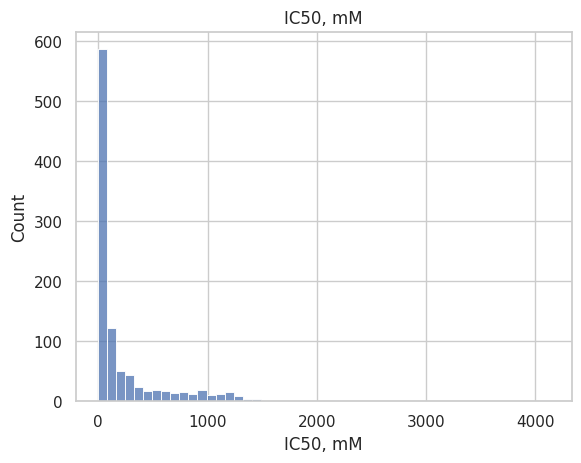

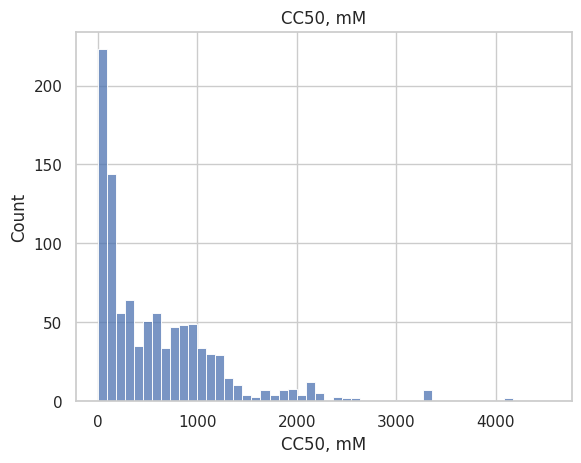

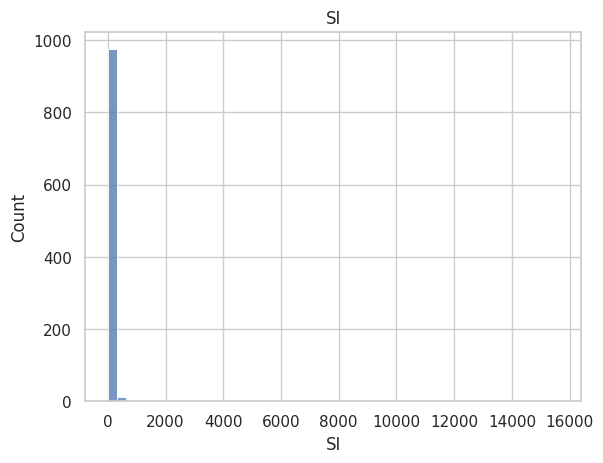

Макс отклонение: 1.8629798432812095e-06


,"IC50, mM","CC50, mM",SI
"IC50, mM",1.000000,0.521346,-0.056604
"CC50, mM",0.521346,1.000000,-0.006818
SI,-0.056604,-0.006818,1.000000


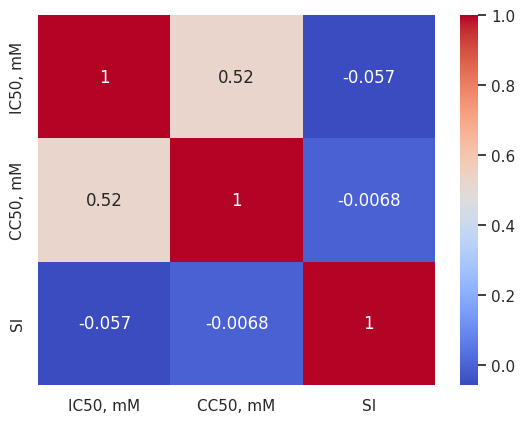

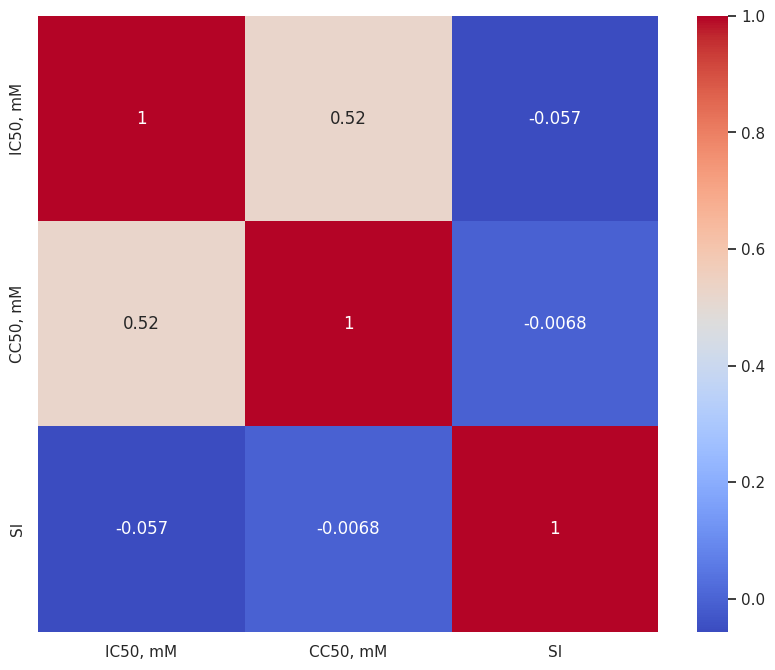

In [ ]:

# 1. Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')



# 2. Загрузка данных

sheet_id = "1q-nbWuFrfrIBMXmZfNW78N3bx5v60Vb9"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

df = pd.read_csv(url)

print("Размер:", df.shape)
display(df.head())



# 3. Общая информация

df.info()

display(df.describe().T)


# 4. Пропуски

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])



# 5. Дубликаты

print("Дубликаты:", df.duplicated().sum())



# 6. Распределения таргетов

targets = ['IC50, mM', 'CC50, mM', 'SI']

for col in targets:
    plt.figure()
    sns.histplot(df[col], bins=50)
    plt.title(col)
    plt.show()



# 7. Проверка SI = CC50 / IC50

df['SI_calc'] = df['CC50, mM'] / df['IC50, mM']
df['diff'] = df['SI'] - df['SI_calc']

print("Макс отклонение:", df['diff'].abs().max())



# 8. Корреляции таргетов

corr = df[['IC50, mM', 'CC50, mM', 'SI']].corr()
display(corr)

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()



# 9. Общая корреляция признаков

plt.figure(figsize=(10,8))
sns.heatmap(df[targets].corr(), annot=True, cmap='coolwarm')
plt.show()